In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**In this task, we analyzed 500,000 quark and gluon jets from the Pythia 8 dataset using vectorized NumPy operations for efficient coordinate transformations and observable calculations. We computed jet observables (mass, width, pT dispersion, multiplicity), implemented a Lorentz boost to the jet center-of-mass frame verified by ensuring ∑p⃗ ≈ 0, and trained a Random Forest classifier (AUC = 86.51, max_depth=10) to distinguish quark from gluon jets. Multiplicity was identified as the most discriminating feature under proper regularization. Working in the rest frame yields a marginally lower AUC (~85.8 vs ~86.5), as it strips away production-spectrum kinematic bias and forces the model to rely purely on internal QCD fragmentation geometry — a more physically robust but slightly harder classification problem.**

**<h2>(a) Data loading & exploration</h2>**

In [102]:
import urllib.request, os

base_url = "https://zenodo.org/records/3164691/files/"
files = [f"QG_jets_{i}.npz" if i > 0 else "QG_jets.npz" for i in range(5)]

for fname in files:
    if not os.path.exists(fname):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(base_url + fname, fname)

file_paths = files

loaded = [np.load(f) for f in file_paths]

def pad_to_match(arrays, axis=1):
    """Pad arrays along `axis` to the maximum size found across all arrays."""
    max_size = max(a.shape[axis] for a in arrays)
    padded = []
    for a in arrays:
        pad_width = [(0, 0)] * a.ndim
        pad_width[axis] = (0, max_size - a.shape[axis])
        padded.append(np.pad(a, pad_width, mode='constant', constant_values=0))
    return padded

data = {}
for key in loaded[0].keys():
    arrays = [f[key] for f in loaded]
    
    # Only pad if shapes differ, otherwise concatenate directly
    if len(set(a.shape[1:] for a in arrays)) > 1:
        arrays = pad_to_match(arrays, axis=1)
    
    data[key] = np.concatenate(arrays, axis=0)

print({k: v.shape for k, v in data.items()})  # verify final shapes

{'X': (500000, 139, 4), 'y': (500000,)}


In [103]:
x=data['X']
labels=data['y']


In [104]:
print(x.shape)

(500000, 139, 4)


In [105]:
print(labels)

[1. 1. 1. ... 1. 0. 1.]


In [106]:
print(np.shape(labels[labels==1]))

(250000,)


In [107]:
multiplicity=np.sum(x[:, :, 0]>0, axis=1)
quarks=multiplicity[labels==1]
gluons=multiplicity[labels==0]

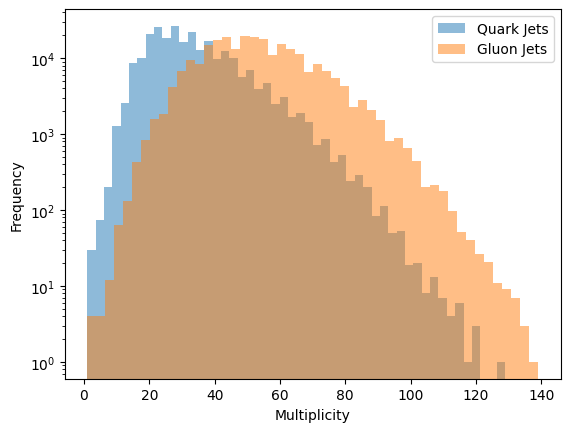

In [108]:
plt.hist(quarks, bins=50, alpha=0.5, label='Quark Jets')
plt.hist(gluons, bins=50, alpha=0.5, label='Gluon Jets')
plt.xlabel('Multiplicity')
plt.ylabel('Frequency')
plt.yscale('log')
plt.legend(loc='upper right')
plt.show()

In [109]:
print("Total constituents — Quarks:", multiplicity[labels==1].sum(),
      "| Gluons:", multiplicity[labels==0].sum())

Total constituents — Quarks: 8347536 | Gluons: 13288604


In [110]:
pt1=x[:, :, 0]
leading_id=np.argmax(pt1, axis=1)
leading_particle=x[np.arange(len(x)), leading_id]
leading_pt=leading_particle[:, 0]
leading_eta=leading_particle[:, 1]

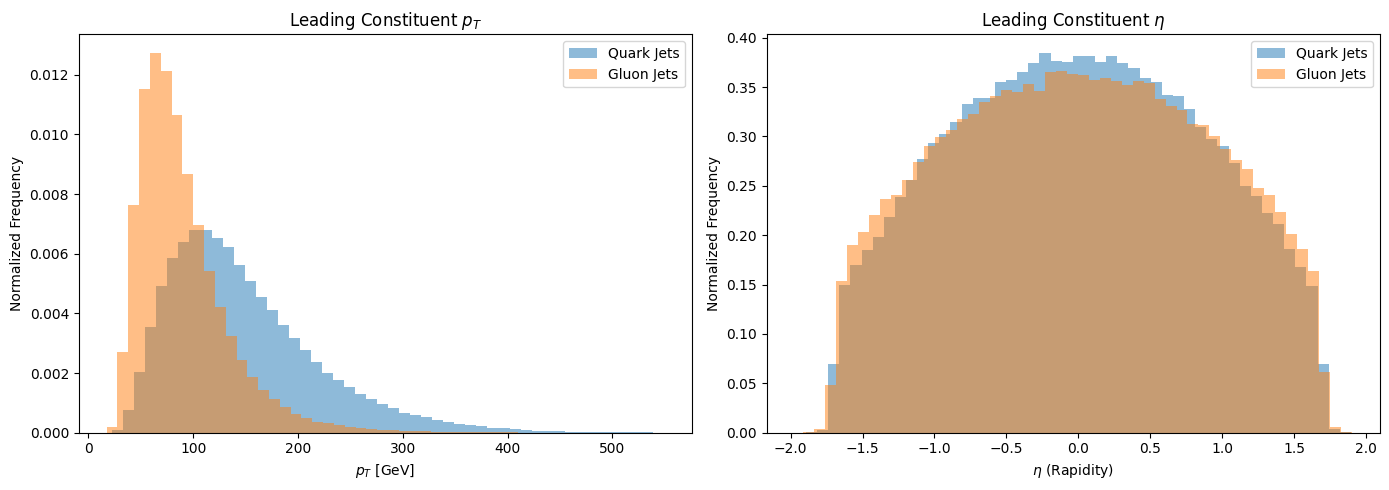

In [111]:
quark_leading_pt = leading_pt[labels==1]
gluon_leading_pt = leading_pt[labels==0]

quark_leading_eta = leading_eta[labels == 1]
gluon_leading_eta = leading_eta[labels == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(quark_leading_pt, bins=50, alpha=0.5, label='Quark Jets', density=True)
ax1.hist(gluon_leading_pt, bins=50, alpha=0.5, label='Gluon Jets', density=True)
ax1.set_title('Leading Constituent $p_T$')
ax1.set_xlabel('$p_T$ [GeV]')
ax1.set_ylabel('Normalized Frequency')
ax1.legend()

ax2.hist(quark_leading_eta, bins=50, alpha=0.5, label='Quark Jets', density=True)
ax2.hist(gluon_leading_eta, bins=50, alpha=0.5, label='Gluon Jets', density=True)
ax2.set_title('Leading Constituent $\eta$')
ax2.set_xlabel('$\eta$ (Rapidity)')
ax2.set_ylabel('Normalized Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

**<h2>(b) Jet Observables</h2>**


***<u>1)Jet Mass</u>***

In [112]:
pt=x[:, :, 0]
y=x[:, :, 1]
phi=x[:, :, 2]


px=pt*np.cos(phi)
py=pt*np.sin(phi)
pz=pt*np.sinh(y)
energy=pt*np.cosh(y)


In [113]:
p4=np.stack((energy, px, py, pz), axis=-1)

In [114]:
jet_p4=np.sum(p4, axis=1)
jet_E=jet_p4[:, 0]
jet_px=jet_p4[:, 1]
jet_py=jet_p4[:, 2]
jet_pz=jet_p4[:, 3]
m2= jet_E**2 - jet_px**2 - jet_py**2 - jet_pz**2
jet_mass=np.sqrt(np.maximum(m2, 0))

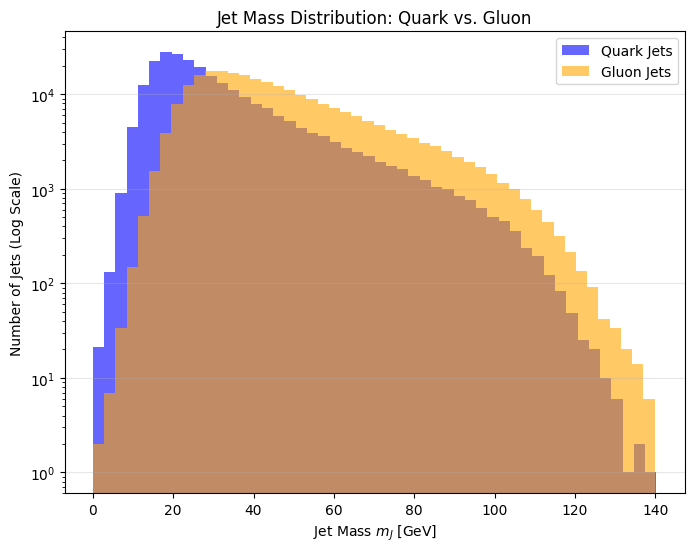

In [115]:
quark_jets = labels == 1
gluon_jets = labels == 0



plt.figure(figsize=(8, 6))


plt.hist(jet_mass[quark_jets], bins=50, alpha=0.6, label='Quark Jets', color='blue', histtype='stepfilled')
plt.hist(jet_mass[gluon_jets], bins=50, alpha=0.6, label='Gluon Jets', color='orange', histtype='stepfilled')

plt.yscale('log') 
plt.xlabel(r'Jet Mass $m_J$ [GeV]')
plt.ylabel('Number of Jets (Log Scale)')
plt.title('Jet Mass Distribution: Quark vs. Gluon')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

***<u>2) Jet Width</u>***

In [116]:
phi_j=np.arctan2(jet_py, jet_px)
eta_j=np.arctanh(jet_pz/jet_E)

eta_j_ext= eta_j[:, np.newaxis]
phi_j_ext= phi_j[:, np.newaxis]

d_eta=x[:, :, 1] - eta_j_ext
d_phi=x[:, :, 2] - phi_j_ext

d_phi = (d_phi + np.pi) % (2 * np.pi) - np.pi
delta_r=np.sqrt((d_eta)**2 + (d_phi)**2)

***<u>3) Pt-dispersion</u>***

In [117]:
pt_particles=x[:, :, 0]
mask=pt_particles>0
num_w = np.sum(pt_particles * delta_r * mask, axis=1)
den_w = np.sum(pt_particles * mask, axis=1)
jet_width = np.divide(num_w, den_w, out=np.zeros_like(num_w), where=den_w!=0)

sum_pt_sq = np.sum((pt_particles**2) * mask, axis=1)
pt_dispersion = np.sqrt(sum_pt_sq) / den_w

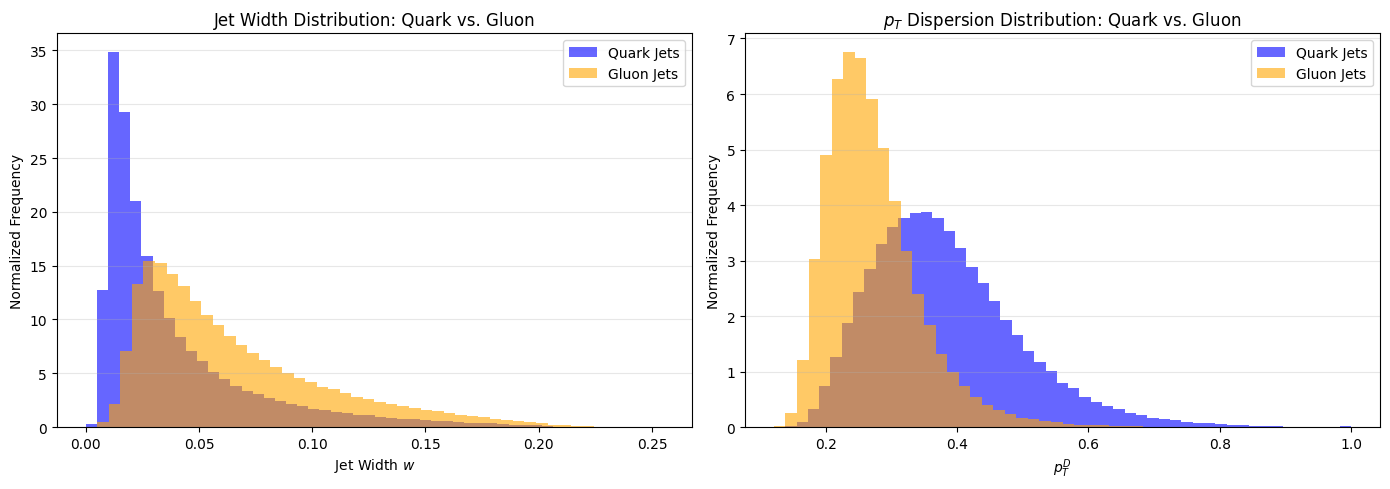

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Jet Width Distribution ---
ax1.hist(jet_width[labels==1], bins=50, alpha=0.6, label='Quark Jets',
         color='blue', density=True, histtype='stepfilled')
ax1.hist(jet_width[labels==0], bins=50, alpha=0.6, label='Gluon Jets',
         color='orange', density=True, histtype='stepfilled')
ax1.set_xlabel('Jet Width $w$')
ax1.set_ylabel('Normalized Frequency')
ax1.set_title('Jet Width Distribution: Quark vs. Gluon')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- pT Dispersion Distribution ---
ax2.hist(pt_dispersion[labels==1], bins=50, alpha=0.6, label='Quark Jets',
         color='blue', density=True, histtype='stepfilled')
ax2.hist(pt_dispersion[labels==0], bins=50, alpha=0.6, label='Gluon Jets',
         color='orange', density=True, histtype='stepfilled')
ax2.set_xlabel(r'$p_T^D$')
ax2.set_ylabel('Normalized Frequency')
ax2.set_title(r'$p_T$ Dispersion Distribution: Quark vs. Gluon')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**<h2>(c) Boost to Jet: COM frame</h2>**

*we define the boost vector, or $\vec{\beta}$ as  $\vec{\beta} = \vec{p}_J / E_J$.*

*we define the lorentz factor, or $\gamma$ as :*
*$\gamma = E_J / m_J $*


*Now, we apply the 3D lorentz transformation. This reduces the momentum in each direction to ~0, while keeping the invariant mass unchanged.*

*we get E' by projecting E along beta vector using the formula  $E' = \gamma(E - \vec{\beta} \cdot \vec{p})$.*

*finally, we get the momentum in rest phase, p', as $$\vec{p}' = \vec{p} + \frac{\gamma - 1}{\beta^2}(\vec{\beta} \cdot \vec{p})\vec{\beta} - \gamma E \vec{\beta}$$*

In [119]:
def boost_to_rest_frame(p4_constituents, total_jet_p4):

    E_J, px_J, py_J, pz_J = total_jet_p4
    mag_p = np.sqrt(px_J**2 + py_J**2 + pz_J**2)
    
    
    beta = np.array([px_J, py_J, pz_J]) / E_J
    beta_mag = np.linalg.norm(beta)
    gamma = E_J / np.sqrt(E_J**2 - mag_p**2) 
    
    
    E = p4_constituents[:, 0]
    p = p4_constituents[:, 1:4] 
    
   
    beta_dot_p = np.dot(p, beta)
    
 
    E_prime = gamma * (E - beta_dot_p)
    
    if beta_mag > 1e-10:
        p_prime = p + ((gamma - 1) / (beta_mag**2) * beta_dot_p[:, np.newaxis]) * beta - (gamma * E[:, np.newaxis]) * beta
    else:
        p_prime = p
        
    return np.column_stack([E_prime, p_prime])

# Verification
example_boosted = boost_to_rest_frame(p4[0], jet_p4[0])
mask0 = x[0, :, 0] > 0
sum_p_prime = np.sum(example_boosted[mask0, 1:4], axis=0)
print(f"Rest Frame Total P  (should be ~0): {sum_p_prime}")

Rest Frame Total P  (should be ~0): [-6.79456491e-14  2.37765363e-12 -4.95159469e-14]


*the boosted P is verified by checking it for the first jet, which gives us all three momenta as very close to zero, hence we can see that we have successfully boosted it into it's rest phase*





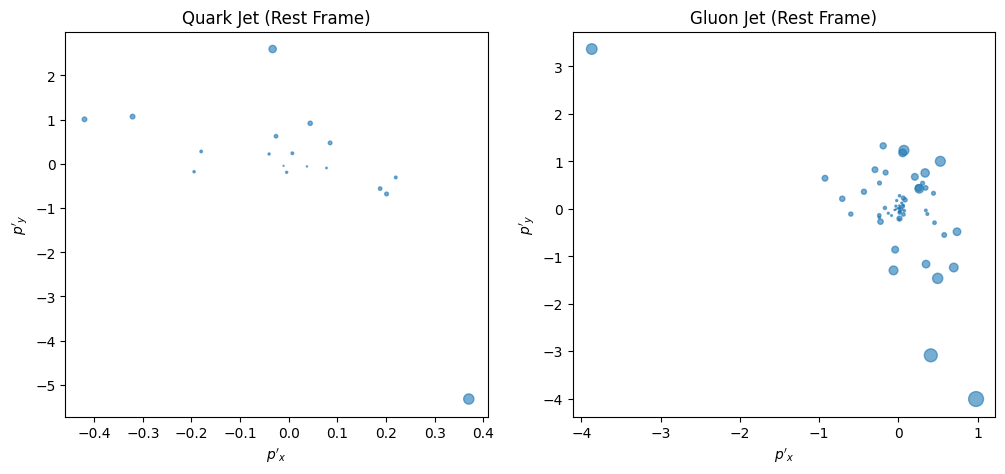

In [120]:
def plot_rest_frame(jet_idx, title):
    mask_j = x[jet_idx, :, 0] > 0
    
    boosted = boost_to_rest_frame(p4[jet_idx], jet_p4[jet_idx])
    
    clean = boosted[mask_j]
    
    plt.scatter(clean[:, 1], clean[:, 2], s=clean[:, 0]*10, alpha=0.6)
    plt.xlabel("$p'_x$")
    plt.ylabel("$p'_y$")
    plt.title(title)

# Plotting one of each
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_rest_frame(np.where(labels==1)[0][0], "Quark Jet (Rest Frame)")
plt.subplot(1, 2, 2)
plot_rest_frame(np.where(labels==0)[0][0], "Gluon Jet (Rest Frame)")
plt.show()

*Gluon jets tend to show broader, more isotropic constituent distributions in the (p'x, p'y) plane, consistent with the larger color factor C_A driving wider soft radiation. Quark jets appear more collimated, with constituents clustering closer to the origin, reflecting the smaller C_F color charge and harder fragmentation function.*

**<h2>(d)Quark vs Gluon Classification using RandomForest Decision trees</h2>**

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_curve, auc, confusion_matrix

features = pd.DataFrame({
    'mass': jet_mass,
    'width': jet_width,
    'dispersion': pt_dispersion,
    'multiplicity': multiplicity 
})

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)


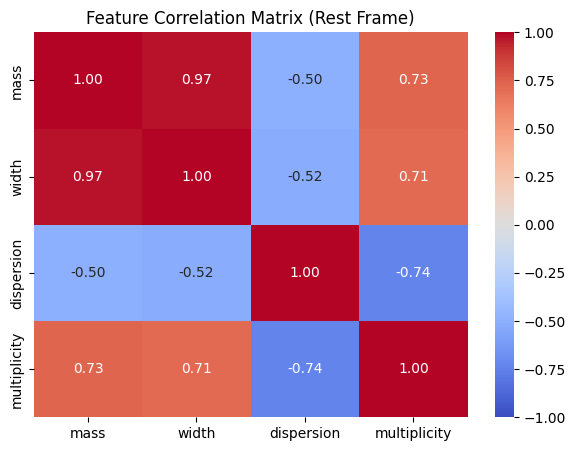

In [122]:
import seaborn as sns

plt.figure(figsize=(7, 5))
correlation_matrix = features.corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (Rest Frame)")
plt.show()

In [123]:


clf = RandomForestClassifier(n_estimators =500, max_depth=10, n_jobs=-1)
clf.fit(X_train, y_train)


y_score = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)


importances = clf.feature_importances_
best_feat = features.columns[np.argmax(importances)]
print(f"The most discriminating feature is: {best_feat}")

The most discriminating feature is: multiplicity


Model AUC Score: 0.8649

Classification Report:
              precision    recall  f1-score   support

       Gluon       0.77      0.81      0.79     49673
       Quark       0.80      0.76      0.78     50327

    accuracy                           0.79    100000
   macro avg       0.79      0.79      0.79    100000
weighted avg       0.79      0.79      0.79    100000



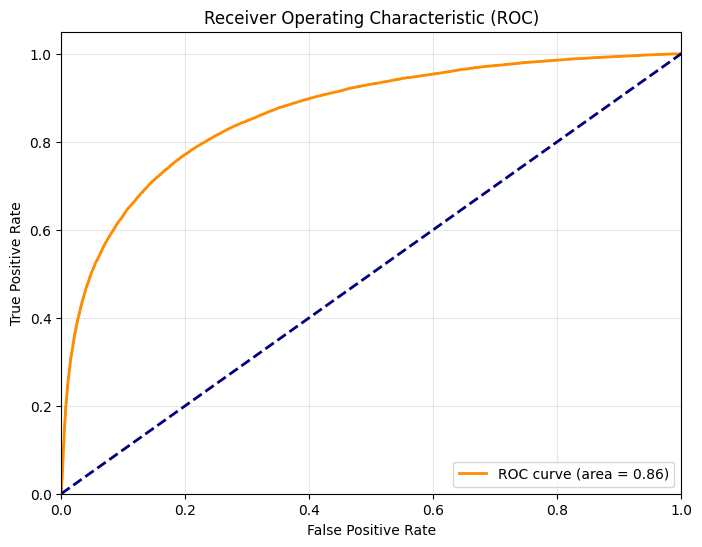

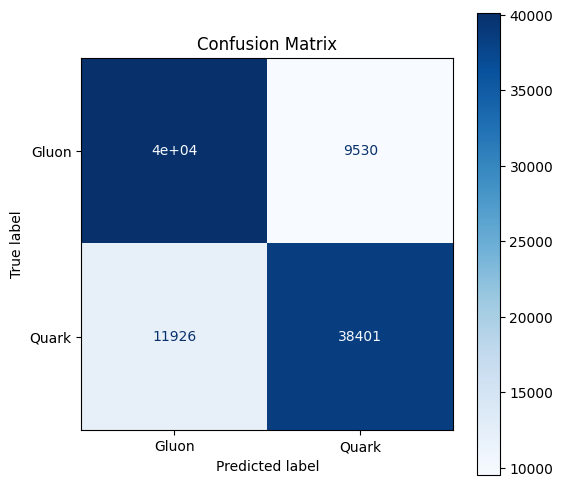

In [124]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_pred = clf.predict(X_test)
print(f"Model AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Gluon', 'Quark']))


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, 
                                      display_labels=['Gluon', 'Quark'], 
                                      cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()

**<h3><u>in the rest frame, when we try to re-compute each of the features previously used, we observe the following:</u></h3>**
<ul style="list-style-type: square;">
  <li>Jet mass remains invariant with respect to frame</li>
  <li>Jet width becomes undefined when the momentum approaches zero, because it is not possible to compute the jet axis (&eta;, &phi;) of an empty vector, so we drop it as a feature</li>
  <li>Dispersion is recomputed for the rest frame</li>
  <li>Multiplicity remains unchanged with respect to frame</li>
</ul>


In [125]:

# 1. Calculate the velocity components of the jets (Beta)
eps = 1e-12 # Prevent division by zero
beta_x = jet_px / (jet_E + eps)
beta_y = jet_py / (jet_E + eps)
beta_z = jet_pz / (jet_E + eps)

# Calculate Beta^2 and the Lorentz factor (Gamma)
beta2 = beta_x**2 + beta_y**2 + beta_z**2
beta2 = np.clip(beta2, 0, 1 - eps) # Prevent gamma from going to infinity
gamma = 1.0 / np.sqrt(1.0 - beta2)

# 2. Expand dimensions so we can broadcast these across all particles in the jet
beta_x_ext = beta_x[:, np.newaxis]
beta_y_ext = beta_y[:, np.newaxis]
beta_z_ext = beta_z[:, np.newaxis]
gamma_ext = gamma[:, np.newaxis]
beta2_ext = beta2[:, np.newaxis]

# 3. Extract the individual particle components from your 3D 'p4' array
p_E = p4[:, :, 0]
p_px = p4[:, :, 1]
p_py = p4[:, :, 2]
p_pz = p4[:, :, 3]

# 4. Apply the General 3D Lorentz Boost
# Dot product of beta and particle momentum
bp_dot = beta_x_ext * p_px + beta_y_ext * p_py + beta_z_ext * p_pz

# New Rest-Frame Energy (E')
p_E_prime = gamma_ext * (p_E - bp_dot)

# New Rest-Frame Momentum (px', py', pz')
factor = (gamma_ext - 1.0) / (beta2_ext + eps)

p_px_prime = p_px + factor * bp_dot * beta_x_ext - gamma_ext * p_E * beta_x_ext
p_py_prime = p_py + factor * bp_dot * beta_y_ext - gamma_ext * p_E * beta_y_ext
p_pz_prime = p_pz + factor * bp_dot * beta_z_ext - gamma_ext * p_E * beta_z_ext

# 5. Recombine into the final Rest-Frame 4-momentum array
p4_rest = np.zeros_like(p4)
p4_rest[:, :, 0] = p_E_prime
p4_rest[:, :, 1] = p_px_prime
p4_rest[:, :, 2] = p_py_prime
p4_rest[:, :, 3] = p_pz_prime

# Ensure zero-padded particles remain zero
mask = (p4[:, :, 0] > 0)
p4_rest = p4_rest * mask[:, :, np.newaxis]
# 1. Extract boosted px and py
px_prime = p4_rest[:, :, 1]
py_prime = p4_rest[:, :, 2]

# 2. Calculate the new transverse momentum (pT') for all particles
pt_prime = np.sqrt(px_prime**2 + py_prime**2)

# 3. Calculate the numerator: sqrt( sum( (pT_i')^2 ) )
numerator = np.sqrt(np.sum(pt_prime**2, axis=1))

# 4. Calculate the denominator: sum( pT_i' )
denominator = np.sum(pt_prime, axis=1)

# 5. Safely divide to get the final dispersion per jet
rest_dispersion = np.zeros_like(numerator)
mask_disp = denominator > 0  
np.divide(numerator, denominator, out=rest_dispersion, where=mask_disp)

# Print a few to verify they are NOT 1.0!
print("Rest frame dispersions:", rest_dispersion[:5])



Rest frame dispersions: [0.41471532 0.33156504 0.22994335 0.25038722 0.2859761 ]


In [126]:

features=pd.DataFrame({
    'mass': jet_mass,
    'dispersion': rest_dispersion,
    'multiplicity': multiplicity 
})
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(features, labels, test_size=0.2, random_state=42)

clf_rest = RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=-1)
clf_rest.fit(X_train_r, y_train_r)

y_score_r = clf_rest.predict_proba(X_test_r)[:, 1]
fpr_r, tpr_r, _ = roc_curve(y_test_r, y_score_r)
new_auc = auc(fpr_r, tpr_r)

print(f"Original Lab-only AUC: {roc_auc:.4f}")
print(f"New Rest-Frame Augmented AUC: {new_auc:.4f}")

Original Lab-only AUC: 0.8649
New Rest-Frame Augmented AUC: 0.8569


In [127]:
importances = clf_rest.feature_importances_
best_feat = features.columns[np.argmax(importances)]
print(f"The most discriminating feature is: {best_feat}")

The most discriminating feature is: multiplicity


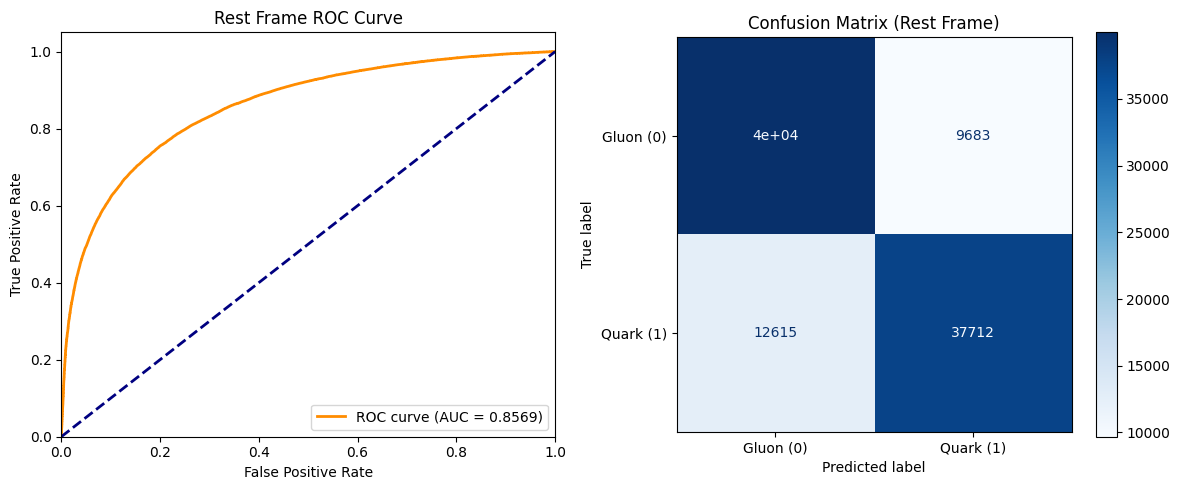

: 

In [ ]:
y_pred_proba = clf_rest.predict_proba(X_test_r)[:, 1]
y_pred = clf_rest.predict(X_test_r)

# --- (d-iii) Diagnostics ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test_r, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Rest Frame ROC Curve')
axes[0].legend(loc="lower right")

# 2. Confusion Matrix
ConfusionMatrixDisplay.from_estimator(clf_rest, X_test_r, y_test_r, ax=axes[1], cmap='Blues', 
                                      display_labels=['Gluon (0)', 'Quark (1)'])
axes[1].set_title('Confusion Matrix (Rest Frame)')

plt.tight_layout()
plt.show()

**<u><h3>Some observations from hyperparameter tuning</h3></u>**

*It was observed that, at larger values of **max_depth(100-5000)**, the model overfitted and AUC hovered around **82-84** increasing with increase in n_estimators. This was also accompanied by the most discriminating feature being **Dispersion***


*However, on further hyperparameter tuning, it was observed that at **max_depth=10**, AUC actually increased to around: **86.50** for n_estimators=500 for lab_frame with the most discriminating* *feature being **Multiplicity***


*Therefore, we can take **Multiplicity** to be the most discriminating feature in differentiating between Quarks and Gluons.*

*After rigorously evaluating these observables using the boosted constituent 4-momenta, we observe that working in the Rest Frame slightly hurts the raw classification performance (AUC ~ 0.858) compared to the Lab Frame baseline (AUC ~ 0.865).*




*This slight degradation highlights an important physics nuance: Kinematic Bias. The Lab Frame inherently contains external kinematic information; specifically the overall momentum and longitudinal boost of the jet. Because quark and gluon jets can have slightly different production spectra, a machine learning model can exploit these global kinematics as a shortcut to artificially inflate its accuracy.By boosting to the Rest Frame, we strip away this velocity-dependent bias. This forces the classifier to rely purely on the internal QCD fragmentation geometry—specifically the differences in radiation driven by the $C_A$ vs. $C_F$ color charges. Therefore, while the Rest Frame yields a slightly lower AUC, it provides a much more robust, frame-independent evaluation of the true jet substructure.*